# Exploring DINO: Self-Supervised Transformers for Road Segmentation with ResNet50 and U-Net

After the success of ImageNet, one of the major shifts in computer vision has been the **rise of self-supervised learning**. Although the concept of self-supervised learning had been around for years, its application in computer vision was limited until methods like **SimCLR** and **BYOL** emerged. Even then, it hadn't fully reached its potential—until Vision Transformers came along. Vision Transformers, with their patch-based processing and attention mechanisms, sparked a wave of new innovations. One groundbreaking approach that merged these two worlds was DINO. DINO is a self-supervised learning method where a **student-teacher model** is trained without labels using a self-distillation process.

In general, self-supervised methods are used for pretraining. Pretraining involves training a model on unlabeled data to help it learn better **feature representations**. Once the pretraining is complete, the model is typically fine-tuned with labeled data in a supervised manner. Since the core of any deep learning model is its ability to capture **robust global and local features**, a feature-rich, pretrained model can then be adapted for a variety of **downstream tasks**, such as classification, segmentation, or object detection. These pretrained models serve as the backbone of the architecture, with one or more specialized heads added based on the specific task at hand.

<br>
<p align="center">
<img src="https://www.dropbox.com/scl/fi/tlv4bp9j4tos2v4f7fchf/dino_resnet.png?rlkey=1a1tqbebaz9bfathze9ecayq3&st=mgy27muy&dl=1" width="700">
</p >
<br>

 Now, we'll be going in depth to understanding how to use a self-supervised pretrained model with a **custom decoder** for performing a downstream segmentation task. Based on aforementioned training approach, we will take a pretrained DINO model—in our case, a pretrained ResNet-50—and fine-tune it for aerial drone imagery segmentation.

 For this task, we will use the <a href="https://ivc.tugraz.at/research-project/semantic-drone-dataset/">Aerial Drone Dataset</a> developed by Institute of Computer Graphics and Vision at Tu Graz university, Austria.

In [1]:
# Install libraries and restart kernel.

!pip install -qqqU wandb transformers==5.0.0 albumentations torchmetrics torchinfo tqdm deepml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.2/27.2 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.3/183.3 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.7/256.7 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 158.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 159.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requir

In [3]:
import os
import random
import zipfile
import warnings
from glob import glob
from dataclasses import dataclass

import cv2
import PIL
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.cuda import amp
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchinfo import summary

# For data augmentation and preprocessing.
import albumentations as A
from albumentations.pytorch import ToTensorV2

# To filter UserWarning.
warnings.filterwarnings("ignore", category=UserWarning)

/Users/sagar.rathod/miniforge3/envs/computer-vision/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/sagar.rathod/miniforge3/envs/computer-vision/lib/python3.12/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## 1 Download and Extract Aerial Drone Dataset


The Semantic Segmentation <a href="https://ivc.tugraz.at/research-project/semantic-drone-dataset/">Drone Dataset</a> is an Aerial Drone dataset developed by Institute of Computer Graphics and Vision at Tu Graz university, Austria.


> The Semantic Drone Dataset focuses on semantic understanding of urban scenes for increasing the safety of autonomous drone flight and landing procedures. The imagery depicts  more than 20 houses from nadir (bird's eye) view acquired at an altitude of 5 to 30 meters above ground. A high resolution camera was used to acquire images at a size of 6000x4000px (24Mpx). The training set contains 400 publicly available images and the test set is made up of 200 private images.


<img src="./images/problem_statement.jpg" width="100%" align=center>

The dataset contains images of from 24 classes as follows:

<img src="./images/aerial_project_dataset_color_code.jpg" width="50%" align=center>

---

We've resized the original dataset while maintaining the aspect ratio. The new dimensions (H, W) are (1000, 1500). This also reduces the download file size from 4GB to ≈330MB. We've also split the dataset into training and validation set before hand.

The dataset has the following file structure:

```html
aerial_dataset_resized
    ├── train
    │   ├── images  [340 samples]
    │   └── masks   [340 samples]
    ├── valid
    │    ├── images [60 samples]
    │    └── masks  [60 samples]
    │
    └── class_dict_seg.csvmasks
```

In [4]:
# To download and unzip processed dataset.

def download_and_unzip(url, save_path):

    print("Downloading and extracting assets...", end="")
    file = requests.get(url)
    open(save_path, "wb").write(file.content)

    try:
        with zipfile.ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0]) # Unzip where downloaded.
            print("Done")
    except:
        print("Invalid file")

In [ ]:
URL = "https://www.dropbox.com/scl/fi/8aqo5uz0z88ffqwfpo4vy/aerial_dataset_resized.zip?rlkey=jo299ill67wk6ltpmzfabvsfw&st=ezgss2vl&dl=1"

dataset_name = "aerial_dataset_resized"
dataset_zip_path = os.path.join(os.getcwd(), f"{dataset_name}.zip")
dataset_path = os.path.join(os.getcwd(), dataset_name)

# Download if dataset does not exists.
if not os.path.exists(dataset_path):
    download_and_unzip(URL, dataset_zip_path)
    # shutil.rmtree(dataset_zip_path) # Remove the ZIP file to free storage space.

Load the class to RGB Color CSV file. We can see that there are 24 classes in the dataset. The class 0 i.e., `unlabled` is treated as *background class*.

In [5]:
class_df = pd.read_csv(os.path.join(dataset_path, "class_dict_seg.csv"))

NUM_CLASSES = len(class_df)

class_df

,name,r,g,b
0,unlabeled,0,0,0
1,paved-area,128,64,128
2,dirt,130,76,0
3,grass,0,102,0
4,gravel,112,103,87
5,water,28,42,168
6,rocks,48,41,30
7,pool,0,50,89
8,vegetation,107,142,35
9,roof,70,70,70


## 2 Configuration Setup

### 2.1 Device Selection & Benchmarking Behaviour

In [6]:
def get_default_device():
    gpu_available = torch.cuda.is_available()
    return torch.device('cuda' if gpu_available else 'cpu'), gpu_available

In [7]:
def seed_everything(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### 2.2 Training and Dataset Configurations

The original size of the images in the dataset is 1000 x 1500. For our experiment, we've tried 2 image sizes (384, 576) & (341, 512). Both chosen shapes ensure the aspect ratio is maintained. We achieved the best result when the whole image was reshaped to size (384 576). This indicates that using bigger image sizes is beneficial for tasks like semantic segmentation, as there are more details to work with.

Other common approaches are to take random crops of a specific size from the original image and train on the fly or create a dataset of cropped patches of images beforehand.

In [8]:
@dataclass
class DatasetConfig:
    NUM_CLASSES: int = NUM_CLASSES
    IMG_WIDTH:   int = 576
    IMG_HEIGHT:  int = 384

    DATA_TRAIN_IMAGES: str = os.path.join(dataset_path, "train", "images", r"*.jpg")
    DATA_TRAIN_LABELS: str = os.path.join(dataset_path, "train", "masks",  r"*.png")
    DATA_VALID_IMAGES: str = os.path.join(dataset_path, "valid", "images", r"*.jpg")
    DATA_VALID_LABELS: str = os.path.join(dataset_path, "valid", "masks",  r"*.png")

    MEAN: tuple = (0.485, 0.456, 0.406)
    STD:  tuple = (0.229, 0.224, 0.225)

    BACKGROUND_CLS_ID: int = 0

@dataclass
class TrainingConfig:
    BATCH_SIZE:      int = 2
    NUM_EPOCHS:      int = 50
    LEARNING_RATE: float = 3e-4
    NUM_WORKERS:     int = 8
    WEIGHT_DECAY:  float = 1e-4


@dataclass
class InferenceConfig:
    BATCH_SIZE:  int = 2
    NUM_BATCHES: int = 2

@dataclass
class ModelConfig:
    MODEL_NAME:str = "nvidia/segformer-b3-finetuned-ade-512-512" # The SegFormer model variant path to use
                                                                 # from HuggingFace

### 2.3 Initialize WandB

In [9]:
from google.colab import userdata
import wandb

secretName = 'wandb_google_colab_api_key'
wandb.login(userdata.get(secretName))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sagar100rathod to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [10]:
run = wandb.init(project="Aerial-Drone-Imagery-Segmentation",
                 name="DINO-ResNet-UNet")

In [11]:
# Initialize experiment run configurations

from wandb.sdk.wandb_config import Config


HPARAMS: Config = run.config

HPARAMS.IMG_SIZE      = (DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH)
HPARAMS.MODEL_NAME    = ModelConfig.MODEL_NAME
HPARAMS.BATCH_SIZE    = TrainingConfig.BATCH_SIZE
HPARAMS.NUM_EPOCHS    = TrainingConfig.NUM_EPOCHS

HPARAMS.OPTIMIZER     = "AdamW"
HPARAMS.LEARNING_RATE = TrainingConfig.LEARNING_RATE
HPARAMS.WEIGHT_DECAY  = TrainingConfig.WEIGHT_DECAY
HPARAMS.LR_SCHEDULER  = "MultiStepLR"

## 3 Custom Dataset Class

In this section, we are defining our own custom `Dataset` class `CustomSegDataset`. In the  `CustomSegDataset` class, we make use of the famous <a href="https://albumentations.ai/" target="_blank">Albumentations library</a> to apply augmentations to image-mask pairs at the same time. This is necessary in case of geometric augmentations are applied to the training set, in that case, the masks should also be adjusted appropriately.

**Class Methods**: There are 3 required method which needs to be defined in the custom dataset class.

1. `__init__()`: This is the first required method we need to define. In this method, we initialize all the variables we need in the entire class for preparing the dataset. In case of segmentation, this includes the input image paths (`image_paths`) and segmentation masks (`mask_paths`) which are the lists containing the paths to all the images and masks. Along with that, we define the total number of classes and boolean to indicate whether the images and masks belong to the train set or not and the custom image preprocessor of the HuggingFace model.
 * Note that the number of classes `num_classes` is not specifically used but is a good attribute to include in the class as a reference. We also have defined one additional class variable `self.transforms` which holds the necessary preprocessing and augmentation functions to be applied to images and masks.


2. `__len__()`: This is the second required method. This method is used to return the total number of image-mask pairs.


3. `load_file()`: The `load_file()` method is used to load the image or mask from disk and resize it according to the new size `self.image_size`.


4. `setup_transforms()`: This method contains the preprocessing and augmentations that we want to apply to the images and masks. It returns an "container" holding all the functions to be applied in-order.


5.  `__getitem__()`: This is the third required method. Here, the value of the `index` argument keeps increasing. So, on the first iteration, the value is 0, on the second iteration, it is 1, and so on. Inside the function, the following operations are performed in order.
    1. Get the `image_path` and `mask_path` at the `index`.
    2. Load `image` and `mask`.
    3. Then we convert the RGB mask mask images to grayscale images using the `rgb_to_grayscale(...)` function.
    4. Finally, we apply the required preprocessing (and augmemtation in case of training set) transformation and return the image-mask pair.

In [12]:
# Custom Class for creating training and validation (segmentation) dataset objects.

class CustomSegDataset(Dataset):
    def __init__(self, *, num_classes, image_paths, mask_paths=None, is_train=False):

        self.image_paths = image_paths
        self.mask_paths  = mask_paths  # None in case of test set where only images are available.
        self.num_classes = num_classes
        self.is_train    = is_train
        self.transforms  = self.setup_transforms()


    def __len__(self):
        return len(self.image_paths)


    def setup_transforms(self):
        transforms = []

        # Augmentation to be applied to the training set.
        if self.is_train:
            transforms.extend([
                    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
                    A.ShiftScaleRotate(scale_limit=0.2, rotate_limit=0.2, shift_limit=0.3, p=0.5),
            ])

        # Preprocess transforms - Normalization and converting to PyTorch tensor format (HWC --> CHW).
        transforms.extend([
                A.Normalize(mean=DatasetConfig.MEAN, std=DatasetConfig.STD, always_apply=True),
                ToTensorV2(),  # (H, W, C) --> (C, H, W)
        ])
        return A.Compose(transforms)


    def load_file(self, file_path):
        file = Image.open(file_path).convert("RGB")
        return np.array(file)


    def __getitem__(self, index):
        if self.mask_paths:  # True for Training and validation set.

            # Load image and mask file.
            image = self.load_file(self.image_paths[index])
            mask  = self.load_file(self.mask_paths[index])

            # Used for converting RGB mask to a single channel (grayscale) representation.
            # Each value of the singe channel mask represents the pixel's class ID (essentially
            # collapsing the RGB mask into a single channel mask).
            # Shape: (H, W, C) --> (H, W)
            mask = rgb_to_grayscale(mask, color_map=rev_id2color,
                                    background_cls_id=DatasetConfig.BACKGROUND_CLS_ID)

            # Apply Preprocessing (+ Augmentations) transformations to image-mask pair
            transformed = self.transforms(image=image, mask=mask)
            image, mask = transformed["image"], transformed["mask"].to(torch.long)
            return image, mask.to(torch.long)

        else:  # For Test set or when only images are available.

            # Load image.
            image = self.load_file(self.image_paths[index])

            # Apply Preprocessing (+ Augmentations) transformations to image
            transformed = self.transforms(image=image)
            image = transformed["image"]

            return image, self.image_paths[index]

## 4 Utilities and Helper Functions


In this section, we define several utilities and helper functions that will be used further below.

We start by creating a class ID to color mapping dictionaries. The first dictionary defines the color mapping  from class IDs to RGB colors in the original dataset. It is used to map the RGB ground truth masks into a single channel representation that encodes the class IDs.
The second dictionary holds the mapping from RGB colors to class ID's used for converting RGB masks to grayscale masks.

In [13]:
# Create a mapping of class ID to RGB value.
id2color = {idx: (row[1], row[2], row[3]) for idx, row in class_df.iterrows()}

# del id2color[23] # To remove the 'conflicting' class.

DatasetConfig.NUM_CLASSES = len(id2color)

HPARAMS.NUM_CLASSES = DatasetConfig.NUM_CLASSES

print("Updated number of classes", HPARAMS.NUM_CLASSES)

# Re-adding the reverse mapping, which is essential for rgb_to_grayscale
rev_id2color = {value: key for key, value in id2color.items()}

Updated number of classes 24


/tmp/ipykernel_10260/3954499748.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  id2color = {idx: (row[1], row[2], row[3]) for idx, row in class_df.iterrows()}


When preparing the masks in the custom dataset class, we need to convert the RGB images to it's single channel (grayscale) representation where each pixel value corresponds to the class ID of the pixel. The following function performs this conversion.

In [14]:
# Function to convert RGB mask to grayscale labels.
def rgb_to_grayscale(rgb_arr, color_map = rev_id2color, background_cls_id=0):

    # Create empty mask
    h, w = rgb_arr.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    # Vectorized mapping
    flat_img = rgb_arr.reshape((-1, 3))
    flat_mask = np.zeros(flat_img.shape[0], dtype=np.uint8)

    for color, idx in color_map.items():
        matches = np.all(flat_img == color, axis=1)
        flat_mask[matches] = idx

    mask = flat_mask.reshape(h, w)

    return mask

We will also need to make use of the function below that will convert a single channel mask to an RGB representation for visualization purposes. Each class ID in the single-channel mask will be converted to a different color according to the `id2color` dictionary mapping.

In [15]:
# Function to convert a single channel mask representation to an RGB mask.
def num_to_rgb(num_arr, color_map=id2color):
    single_layer = np.squeeze(num_arr)
    output = np.zeros(num_arr.shape[:2] + (3,))

    for k in color_map.keys():
        output[single_layer == k] = color_map[k]

    return np.float32(output) / 255.0 # return a floating point array in range [0.0, 1.0]

Helper function to overlay an RGB segmentation map on top of an RGB image.

In [16]:
# Function to overlay a segmentation map on top of an RGB image.
def image_overlay(image, segmented_image):

    alpha = 1.0 # Transparency for the original image.
    beta  = 0.7 # Transparency for the segmentation map.
    gamma = 0.0 # Scalar added to each sum.

    segmented_image = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR)

    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    image = cv2.addWeighted(image, alpha, segmented_image, beta, gamma, image)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return np.clip(image, 0.0, 1.0)

The convenience function below will display the original image, the ground truth mask, and the ground truth mask overlayed on the original image. Note that there is an optional argument that allows you to control if the ground truth mask is displayed as a grayscale image or a color image.

In [17]:
def display_image_and_mask(*, images, masks, color_mask=False, color_map=id2color):
    title = ["GT Image", "GT Mask", "Color Mask", "Overlayed Mask"]

    for idx in range(images.shape[0]):
        image = images[idx]
        grayscale_gt_mask = masks[idx]

        fig = plt.figure(figsize=(15, 4))

        # Create RGB segmentation map from grayscale segmentation map.
        rgb_gt_mask = num_to_rgb(grayscale_gt_mask, color_map=color_map)

        # Create the overlayed image.
        overlayed_image = image_overlay(image, rgb_gt_mask)

        plt.subplot(1, 4, 1)
        plt.title(title[0])
        plt.imshow(image)
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.title(title[1])
        plt.imshow(grayscale_gt_mask, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.title(title[2])
        plt.imshow(rgb_gt_mask)
        plt.axis("off")

        plt.imshow(rgb_gt_mask)
        plt.subplot(1, 4, 4)
        plt.title(title[3])
        plt.imshow(overlayed_image)
        plt.axis("off")

        plt.show()

    return

## 5 Creating DataLoader Objects

Here we define the `get_dataloader(...)` function to generate training and validation data loader objects. We also create an instance of the `SegformerImageProcessor` class that is passed to the custom dataset class. The parameter values we've used can also be overridden later on when using the `.preprocess(...)` methods.

In [18]:
def get_dataloader(configs=None, num_workers=0, pin_memory=False, shuffle_validation=False, custom_batch_size=None):

    NUM_CLASSES    = configs["NUM_CLASSES"]
    BATCH_SIZE     = configs["BATCH_SIZE"] if not custom_batch_size else custom_batch_size
    HEIGHT, WIDTH  = configs["IMG_SIZE"][0], configs["IMG_SIZE"][1]

    # Create training dataset and dataloader.
    train_images = sorted(glob(f"{DatasetConfig.DATA_TRAIN_IMAGES}"))
    train_masks  = sorted(glob(f"{DatasetConfig.DATA_TRAIN_LABELS}"))

    train_dataset = CustomSegDataset(image_paths=train_images, mask_paths=train_masks, is_train=True,
                                     num_classes=NUM_CLASSES)

    train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,  pin_memory=pin_memory,
                               num_workers=num_workers, drop_last=True, shuffle=True)

    # Create validation dataset and dataloader.
    valid_images = sorted(glob(f"{DatasetConfig.DATA_VALID_IMAGES}"))
    valid_masks  = sorted(glob(f"{DatasetConfig.DATA_VALID_LABELS}"))

    valid_dataset = CustomSegDataset(image_paths=valid_images, mask_paths=valid_masks, is_train=False,
                                     num_classes=NUM_CLASSES)

    valid_loader  = DataLoader(valid_dataset, batch_size=BATCH_SIZE,  pin_memory=pin_memory,
                               num_workers=num_workers, shuffle=shuffle_validation)

    return train_loader, valid_loader

Now we call the above function to create the `DataLoader` objects.

In [19]:
train_loader, valid_loader = get_dataloader(configs=HPARAMS, shuffle_validation=True)

### 5.1 Display Sample Images from the Dataset

In the code cell below, we loop over the first batch in the validation dataset and display the ground truth image, ground truth mask, and the ground truth mask overlayed on the image. The overlay helps us better visualize the segmented classes in the context of the original image.

In [20]:
# This function is used for reversing the Normalization step performed during image preprocessing.
# Note the mean and std values must match the ones used.

def denormalize(tensors, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """Normalization parameters for pre-trained PyTorch models
    Denormalizes image tensors using mean and std"""

    for c in range(3):
        tensors[:, c, :, :].mul_(std[c]).add_(mean[c])

    return torch.clamp(tensors, min=0.0, max=1.0)

batch_images shape: torch.Size([2, 3, 1000, 1500])
batch_masks shape:  torch.Size([2, 1000, 1500])


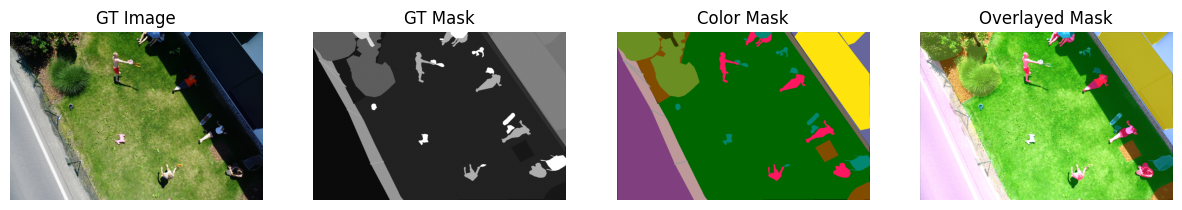

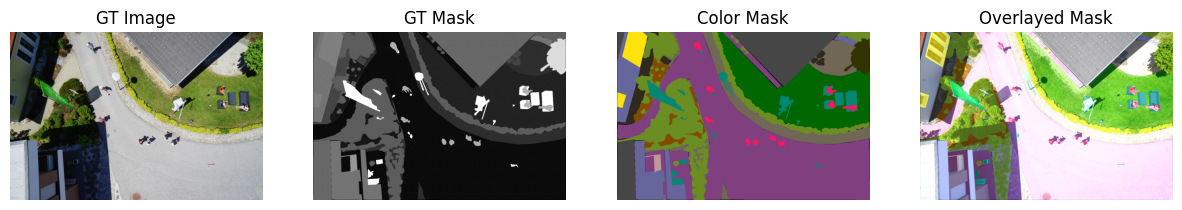

In [21]:
for batch_images, batch_masks in valid_loader:
    print("batch_images shape:", batch_images.shape)
    print("batch_masks shape: ", batch_masks.shape)

    batch_images = denormalize(batch_images, mean=DatasetConfig.MEAN, std=DatasetConfig.STD).permute(0, 2, 3, 1).numpy()
    batch_masks  = batch_masks.numpy()

    display_image_and_mask(images=batch_images, masks=batch_masks, color_mask=True)

    break

## 6 DINO ResNet50 Model Definition


The DINO model is typically known for using Vision Transformers (ViT) as its core architecture, but in this case, we are opting for ResNet50 because it integrates more seamlessly with the U-Net architecture. After training the student-teacher model, the student model, here a ResNet50 trained via DINO, is used as the backbone for downstream tasks such as segmentation. Although the DINO paper's authors experimented with both ViT and CNN-based architectures, we're using ResNet50 for its practical integration with U-Net.

<center><img src="https://www.dropbox.com/scl/fi/almnc0jj08ur25d7m4sg0/dino_vit_cnn_models.png?rlkey=8pmppaa8bbta5e3n7xdzk7nd3&st=1f2fnqp1&dl=1" width="300"></center>

Now, that the objective is defined, let's understand the code.

**Conv2dReLU Block:** This helper block performs a 2D convolution followed by batch normalization and ReLU activation. It simplifies the creation of convolutional layers, especially in both the encoder and decoder sections of the model. This block is mostly used in the decoder block only.

<br>
<p align="center">
<img src="https://www.dropbox.com/scl/fi/vmllidb80t4h1bpkmnqvk/dino_resnet_model.png?rlkey=cmx7n4lmizbzo1hkjzm3topm4&st=pi5swvsa&dl=1" width="700">
</p >
<br>

**DecoderBlock:** The DecoderBlock takes the feature maps from the encoder, upsamples them using bilinear interpolation, and then concatenates them with the corresponding encoder feature maps (from the skip connections, dotted blue arrows in the image). After concatenation, it applies two convolutional layers to refine the combined feature map, enabling the model to generate more detailed outputs.

**DinoUNetResNet50:** This U-Net model uses a pretrained ResNet50 (from the DINO model) as its encoder. The ResNet50 layers (layer0, layer1, layer2, layer3, and layer4 from the image) extract features at different scales. These features are used as input for the decoder blocks, where the segmentation is progressively refined. The model is loaded from `torch.hub`, below are the examples to load other models,

```python
import torch
vits16 = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
vits8 = torch.hub.load('facebookresearch/dino:main', 'dino_vits8')
vitb16 = torch.hub.load('facebookresearch/dino:main', 'dino_vitb16')
vitb8 = torch.hub.load('facebookresearch/dino:main', 'dino_vitb8')
xcit_small_12_p16 = torch.hub.load('facebookresearch/dino:main', 'dino_xcit_small_12_p16')
xcit_small_12_p8 = torch.hub.load('facebookresearch/dino:main', 'dino_xcit_small_12_p8')
xcit_medium_24_p16 = torch.hub.load('facebookresearch/dino:main', 'dino_xcit_medium_24_p16')
xcit_medium_24_p8 = torch.hub.load('facebookresearch/dino:main', 'dino_xcit_medium_24_p8')
resnet50 = torch.hub.load('facebookresearch/dino:main', 'dino_resnet50')
```




By leveraging this architecture, we can effectively use the pretrained ResNet50 model from DINO as the backbone for the U-Net architecture, ensuring that the model benefits from the rich feature representations learned through self-supervised learning. This setup allows the model to produce high-quality segmentation maps for tasks such as road segmentation.

In [22]:
class Conv2dReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super(Conv2dReLU, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DecoderBlock, self).__init__()
        self.conv1 = Conv2dReLU(in_channels, out_channels)
        self.conv2 = Conv2dReLU(out_channels, out_channels)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

    def forward(self, x, skip):
        # Upsample
        x = self.up(x)

        # Resize skip connection to match the size of x
        if x.size() != skip.size():
            skip = F.interpolate(skip, size=x.shape[2:], mode='bilinear', align_corners=True)

        # Concatenate the skip connection (encoder output)
        x = torch.cat([x, skip], dim=1)

        # Apply convolutions
        x = self.conv1(x)
        x = self.conv2(x)
        return x

class DinoUNetResNet50(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super(DinoUNetResNet50, self).__init__()

        # Load ResNet50 pre-trained on ImageNet
        self.encoder = torch.hub.load('facebookresearch/dino:main', 'dino_resnet50')


        # Encoder layers from ResNet-50 (for skip connections)
        self.encoder_layers = [
            nn.Sequential(self.encoder.conv1, self.encoder.bn1, self.encoder.relu, self.encoder.maxpool),  # (64, H/4, W/4)
            self.encoder.layer1,  # (256, H/4, W/4)
            self.encoder.layer2,  # (512, H/8, W/8)
            self.encoder.layer3,  # (1024, H/16, W/16)
            self.encoder.layer4   # (2048, H/32, W/32)
        ]

        # Decoder (Upsampling blocks)
        self.decoder4 = DecoderBlock(2048 + 1024, 512)  # Block for layer4 + layer3
        self.decoder3 = DecoderBlock(512 + 512, 256)    # Block for layer3 + layer2
        self.decoder2 = DecoderBlock(256 + 256, 128)    # Block for layer2 + layer1
        self.decoder1 = DecoderBlock(128 + 64, 64)      # Block for layer1 + conv1

        # Final segmentation head
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(64, num_classes, kernel_size=3, padding=1),
        )

    def forward(self, x):
        # Save original input size for final upsampling
        original_size = x.shape[2:]  # (H, W)

        # Encoder forward pass
        x0 = self.encoder_layers[0](x)  # Initial convolution block (conv1)
        x1 = self.encoder_layers[1](x0)  # Skip connection 1 (layer1)
        x2 = self.encoder_layers[2](x1)  # Skip connection 2 (layer2)
        x3 = self.encoder_layers[3](x2)  # Skip connection 3 (layer3)
        x4 = self.encoder_layers[4](x3)  # Skip connection 4 (layer4)

        # Decoder forward pass
        x = self.decoder4(x4, x3)  # Decoder for layer4 + skip3
        x = self.decoder3(x, x2)   # Decoder for layer3 + skip2
        x = self.decoder2(x, x1)   # Decoder for layer2 + skip1
        x = self.decoder1(x, x0)    # Decoder for layer1 + initial conv1 output

        # Upsample the final output to match the input size dynamically
        x = F.interpolate(x, size=original_size, mode='bilinear', align_corners=True)

        # Final segmentation output
        x = self.segmentation_head(x)

        return x

**Usage**

In [23]:
model = DinoUNetResNet50(num_classes=DatasetConfig.NUM_CLASSES, pretrained=True)

summary(model, (1, 3, DatasetConfig.IMG_WIDTH, DatasetConfig.IMG_HEIGHT))

Downloading: "https://github.com/facebookresearch/dino/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dino/dino_resnet50_pretrain/dino_resnet50_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dino_resnet50_pretrain.pth


100%|██████████| 90.0M/90.0M [00:01<00:00, 77.3MB/s]


Layer (type:depth-idx)                        Output Shape              Param #
DinoUNetResNet50                              [1, 24, 576, 384]         --
├─ResNet: 1-1                                 --                        --
│    └─Conv2d: 2-1                            [1, 64, 288, 192]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 288, 192]         128
│    └─ReLU: 2-3                              [1, 64, 288, 192]         --
│    └─MaxPool2d: 2-4                         [1, 64, 144, 96]          --
│    └─Sequential: 2-5                        [1, 256, 144, 96]         --
│    │    └─Bottleneck: 3-1                   [1, 256, 144, 96]         75,008
│    │    └─Bottleneck: 3-2                   [1, 256, 144, 96]         70,400
│    │    └─Bottleneck: 3-3                   [1, 256, 144, 96]         70,400
│    └─Sequential: 2-6                        [1, 512, 72, 48]          --
│    │    └─Bottleneck: 3-4                   [1, 512, 72, 48]          379,392

In [24]:
# Create dummy inputs.
data    = torch.randn(1, 3, *HPARAMS.IMG_SIZE)
target = torch.rand(1, *HPARAMS.IMG_SIZE).to(torch.long)

data.shape, target.shape

(torch.Size([1, 3, 384, 576]), torch.Size([1, 384, 576]))

## 7  Custom Accuracy Metric and Loss Function

In this section, we are defining the **classwise `mean_iou(...)`** custom metric function and the **Combo `dice_coef_loss(...)`** loss function.

### 7.1 Mean IoU Metric

Intersection over Union (IoU) is a metric often used in segmentation problems to assess the model's "accuracy". It provides a more intuitive basis for accuracy that is not biased by the (unbalanced) percentage of pixels from any particular class.


Given two segmentation masks `A` and `B`, the IoU is defined as follows:

$$
IoU = \frac{|A\cap B\hspace{1mm}|}{|A\cup B\hspace{1mm}|} = \frac{TP}{TP + FP + FN} \hspace{2mm}
$$


When multiple classes and inferences exist, we assess the model's performance by computing the mean IoU. The function below computes the mean IoU that only considers the classes that are present in the ground truth mask or the predicted segmentation map (sometimes referred to as classwise mean IoU). This computation is a better representation for the metric since it only conisders the relevant classes. **This is the metric computation we use for mean IoU.**

In [25]:
class MeanIoU(torch.nn.Module):

    def __init__(self, num_classes: int) -> None:
        super().__init__()
        self.num_classes = num_classes

    def forward(self, predictions, ground_truths, dims = (1, 2)):
        """
        Arguments:
        predictions (torch.tensor): model Predictions (P).
                                    Shape: [batch_size(B), height(H), width(W)]

        ground_truths (torch.tensor): Ground truth mask (G). Shape: [B, H, W]

        dims (tuple): Dimensions corresponding to image height and width in a tensor shape: [B, H, W, C].

        return (scalar): Mean IoU metric.
        """

        # Convert single channel ground truth masks into one-hot encoded tensor.
        # Shape: [B, H, W] --> [B, H, W, num_classes]
        ground_truths = F.one_hot(ground_truths, num_classes=self.num_classes).permute(0, 3, 1, 2).to(DEVICE) # Permute to match the shape of predictions.

        # Converting unnormalized predictions into one-hot encoded across channels.
        # Shape: [B, H, W] --> [B, H, W, num_classes]
        predictions = F.softmax(predictions, dim=1)

        # Intersection: |G ∩ P|. Shape: [B, num_classes]
        intersection = (predictions * ground_truths).sum(dim=dims)

        # Summation: |G| + |P|. Shape: [B, num_classes].
        summation = (predictions.sum(dim=dims) + ground_truths.sum(dim=dims))

        # Union. Shape: [B, num_classes]
        union = summation - intersection

        # IoU Shape: [B, num_classes]
        iou = intersection / union

        # As no smoothing is used we replace any 'nan' value that with 0.
        # With smoothing the results yields slightly different values.
        iou = torch.nan_to_num(iou, nan=0.0)

        # Shape: [batch_size,]
        num_classes_present = torch.count_nonzero(summation, dim=1)

        # IoU per image.
        # Average over the total number of classes present in ground_truths and predictions.
        # Shape: [batch_size,]
        iou = iou.sum(dim=1) / num_classes_present

        # Compute the mean over the remaining axes (batch and classes).
        # Shape: Scalar
        iou_mean = iou.mean()

        return iou_mean

### 7.2  Dice + Cross Entropy Loss

The Dice Coefficient (otherwise known as the F1-Score) is another metric that is used in the context of segmentation. It is often used as the basis of a loss function for segmentation problems. It's widespread use is mainly empirical.

For a binary classification problem, the metric is defined as follows using set notation, where `A` and `B` are segmentation masks representing the ground truth mask and the predicted segmentation map.
<br>

$$
Dice = \frac{2*|A\cap B\hspace{1mm}|}{|A\hspace{1mm}| + |B\hspace{1mm}|} \hspace{2mm} =  \hspace{2mm} \frac{2TP}{2TP + FP + FN}
$$

Simply put, the metric is twice the overlap area divided by the total number of pixels in both images. As you can see, the Dice Coefficient is very similar to IoU. Both metrics range from `0` to `1` and are positively correlated with each other.

Note that the Dice Coefficient can also be used as an accuracy metric, but since mean IoU is more intuitive and most often quoted in the literature, we will use mean IoU as the primary metric for evaluating segmentation models.

Just as we previously defined functions for custom accuracy metrics, we can define custom loss functions similarly. Below we define a custom loss function often used in segmentation problems when there is an imbalance in the classes within the dataset.

The loss is based on the **Dice metric combined with cross-entropy (CE) loss.** In practice, we have found that using a combined loss (Dice loss + CE loss) works better than Dice loss alone.

In [26]:
class DiceCOELoss(torch.nn.Module):

    def __init__(self, num_classes: int, smooth: float = 1e-8) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, predictions, ground_truths, dims = (1, 2)):
        """
        Naive Dice coefficient + Cross-entropy loss function.

        Arguments:
        predictions (torch.tensor): Prediction (P) model output logits.
                                    Shape: [batch_size(B), num_classes, height(H), width(W)]

        ground_truths (torch.tensor): Ground truth mask (G). [B, num_classes, H, W].
        dims (tuple): Dimensions corresponding to image height and width in a tensor shape: [B, H, W, num_classes].

        return (scalar): Combo loss of dice + CE with equal weighting.
        """

        # Convert single channel ground truth masks into one-hot encoded tensor.
        # Shape: (B, H, W) -> (B, num_classes, H, W)
        ground_truths = ground_truths.to(DEVICE)
        ground_truth_oh = F.one_hot(ground_truths, num_classes=self.num_classes).permute((0, -1, 1, 2)).to(DEVICE)

        # Normalize model predictions and transpose.
        # Shape :: [B, num_classes, H, W]
        # This is done to match the shape of ground_truth_oh.

        prediction_norm = F.softmax(predictions, dim=1)
        # Intersection: |G ∩ P|. Shape: [B, num_classes]
        intersection = (prediction_norm * ground_truth_oh).sum(dim=dims)

        # Summation: |G| + |P|. Shape: [B, num_classes].
        summation = (prediction_norm.sum(dim=dims) + ground_truth_oh.sum(dim=dims))

        # Dice Shape: [B, num_classes]
        dice = (2.0 * intersection + self.smooth) / (summation + self.smooth)

        # Compute the mean over the remaining axes (batch and classes).
        dice_mean = dice.mean()

        # Compute cross-entropy loss.
        CE = F.cross_entropy(predictions, ground_truths)

        return (1.0 - dice_mean) + CE

## 8 Set Reproducibility

In [27]:
# For deterministic training
seed_everything(seed_value=41)

# Set default device to GPU if available.
DEVICE, GPU_AVAILABLE = get_default_device()

## 8.1 Define Segmentation Task

In [28]:
from deepml.tasks import Segmentation

segmentation_task = Segmentation(model=model,
                                 model_dir=wandb.run.dir,
                                 device=str(DEVICE),
                                 num_classes=DatasetConfig.NUM_CLASSES,
                                 mode="multiclass")

## 8.2 Define Optimizer and Learning Rate Scheduler

In [29]:
# Initialize Optimizer.
LR = HPARAMS["LEARNING_RATE"]
WD = HPARAMS["WEIGHT_DECAY"]

if HPARAMS["OPTIMIZER"] in ("AdamW", "Adam"):
    optimizer = getattr(torch.optim, HPARAMS["OPTIMIZER"])(model.parameters(), lr=LR, weight_decay=WD, amsgrad=True)
else:
    optimizer = optim.SGD(model.parameters(), lr=LR, weight_decay=WD)


# Intialize learning rate scheduler.
if HPARAMS["LR_SCHEDULER"]:
    milestones = [HPARAMS["NUM_EPOCHS"] // 2,]  # Decrease LR by 0.1 after 50% of traiining.
    HPARAMS["SCHLR_MILESTONES"] = milestones

    lr_scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=HPARAMS["SCHLR_MILESTONES"], gamma=0.1)

# # Compile the model if you are using PyTorch 2.0.
# model = torch.compile(model)

## 9 Model Training

We use **`Learner`** class as experiment runs on a single GPU (or CPU). It is the lightest-weight option — no distributed setup overhead — and integrates cleanly with Jupyter notebooks by printing live progress bars and real-time metrics directly in the cell output.

`Learner` wraps the `HuggingFaceTask` (our custom `Segmentation` subclass) and wires together:

- **`criterion`** — `DiceCOELoss` for pixel-wise segmentation loss.
- **`optimizer`** — configured in the previous step (AdamW / Adam / SGD).
- **`lr_scheduler`** — `MultiStepLR`, stepped per **epoch** (`lr_scheduler_step_policy="epoch"`).

Once constructed, `trainer.fit(...)` handles the full training loop, validation, metric logging, and checkpoint saving automatically.

In [30]:
from deepml.trainer import Learner

criterion = DiceCOELoss(num_classes=DatasetConfig.NUM_CLASSES)

trainer = Learner(segmentation_task, optimizer=optimizer, criterion=criterion,
                            lr_scheduler=lr_scheduler,
                             lr_scheduler_step_policy="epoch",
                              )

In [31]:
# Create Dataloader.
train_loader, valid_loader = get_dataloader(configs=HPARAMS, pin_memory=False,
                                            num_workers=TrainingConfig.NUM_WORKERS)

### 10 Launch Training and Track Metrics

At this stage, all training components are ready:

- the `trainer` wraps the model, optimizer, loss, and learning-rate scheduler,
- the dataloaders provide batched training and validation samples,
- and `WandbLogger` records losses, metrics, and visual outputs for experiment tracking.

In the next cell, `trainer.fit(...)` starts the end-to-end training loop. During each epoch, it trains on the training loader, evaluates on the validation loader, logs the mean IoU metric, and stores example segmentation outputs after applying `ImageNetInverseTransform` so the logged images are human-readable.

In [32]:
from deepml.transforms import ImageNetInverseTransform
from deepml.tracking import WandbLogger

logger = WandbLogger()

trainer.fit(train_loader=train_loader, val_loader=valid_loader,
            epochs=HPARAMS["NUM_EPOCHS"],
            logger=logger,
            metrics={'meanIoU': MeanIoU(num_classes=DatasetConfig.NUM_CLASSES)},
            logger_img_size=HPARAMS["IMG_SIZE"],
            image_inverse_transform=ImageNetInverseTransform())

Epoch 1/50:


Validation  : 100%|██████████| 30/30 [00:14<00:00,  2.09it/s, loss=1.393, meanIoU=0.4735]


Training Loss: 1.9330 Validation Loss: 1.3930 [Saving best validation model]
Epoch 2/50:


Validation  : 100%|██████████| 30/30 [00:13<00:00,  2.19it/s, loss=1.0727, meanIoU=0.599]


Training Loss: 1.2949 Validation Loss: 1.0727 [Saving best validation model]
Epoch 3/50:


...

Training Loss: 0.2275 Validation Loss: 0.4141 
Epoch 49/50:


Validation  : 100%|██████████| 30/30 [00:14<00:00,  2.11it/s, loss=0.3988, meanIoU=0.8226]


Training Loss: 0.2265 Validation Loss: 0.3988 
Epoch 50/50:


Validation  : 100%|██████████| 30/30 [00:13<00:00,  2.29it/s, loss=0.4041, meanIoU=0.8208]


Training Loss: 0.2290 Validation Loss: 0.4041 


## 11 Inference

For inference, we will use the same validation data as we did during training. We will plot the ground truth images, the ground truth masks, and the predicted segmentation masks.

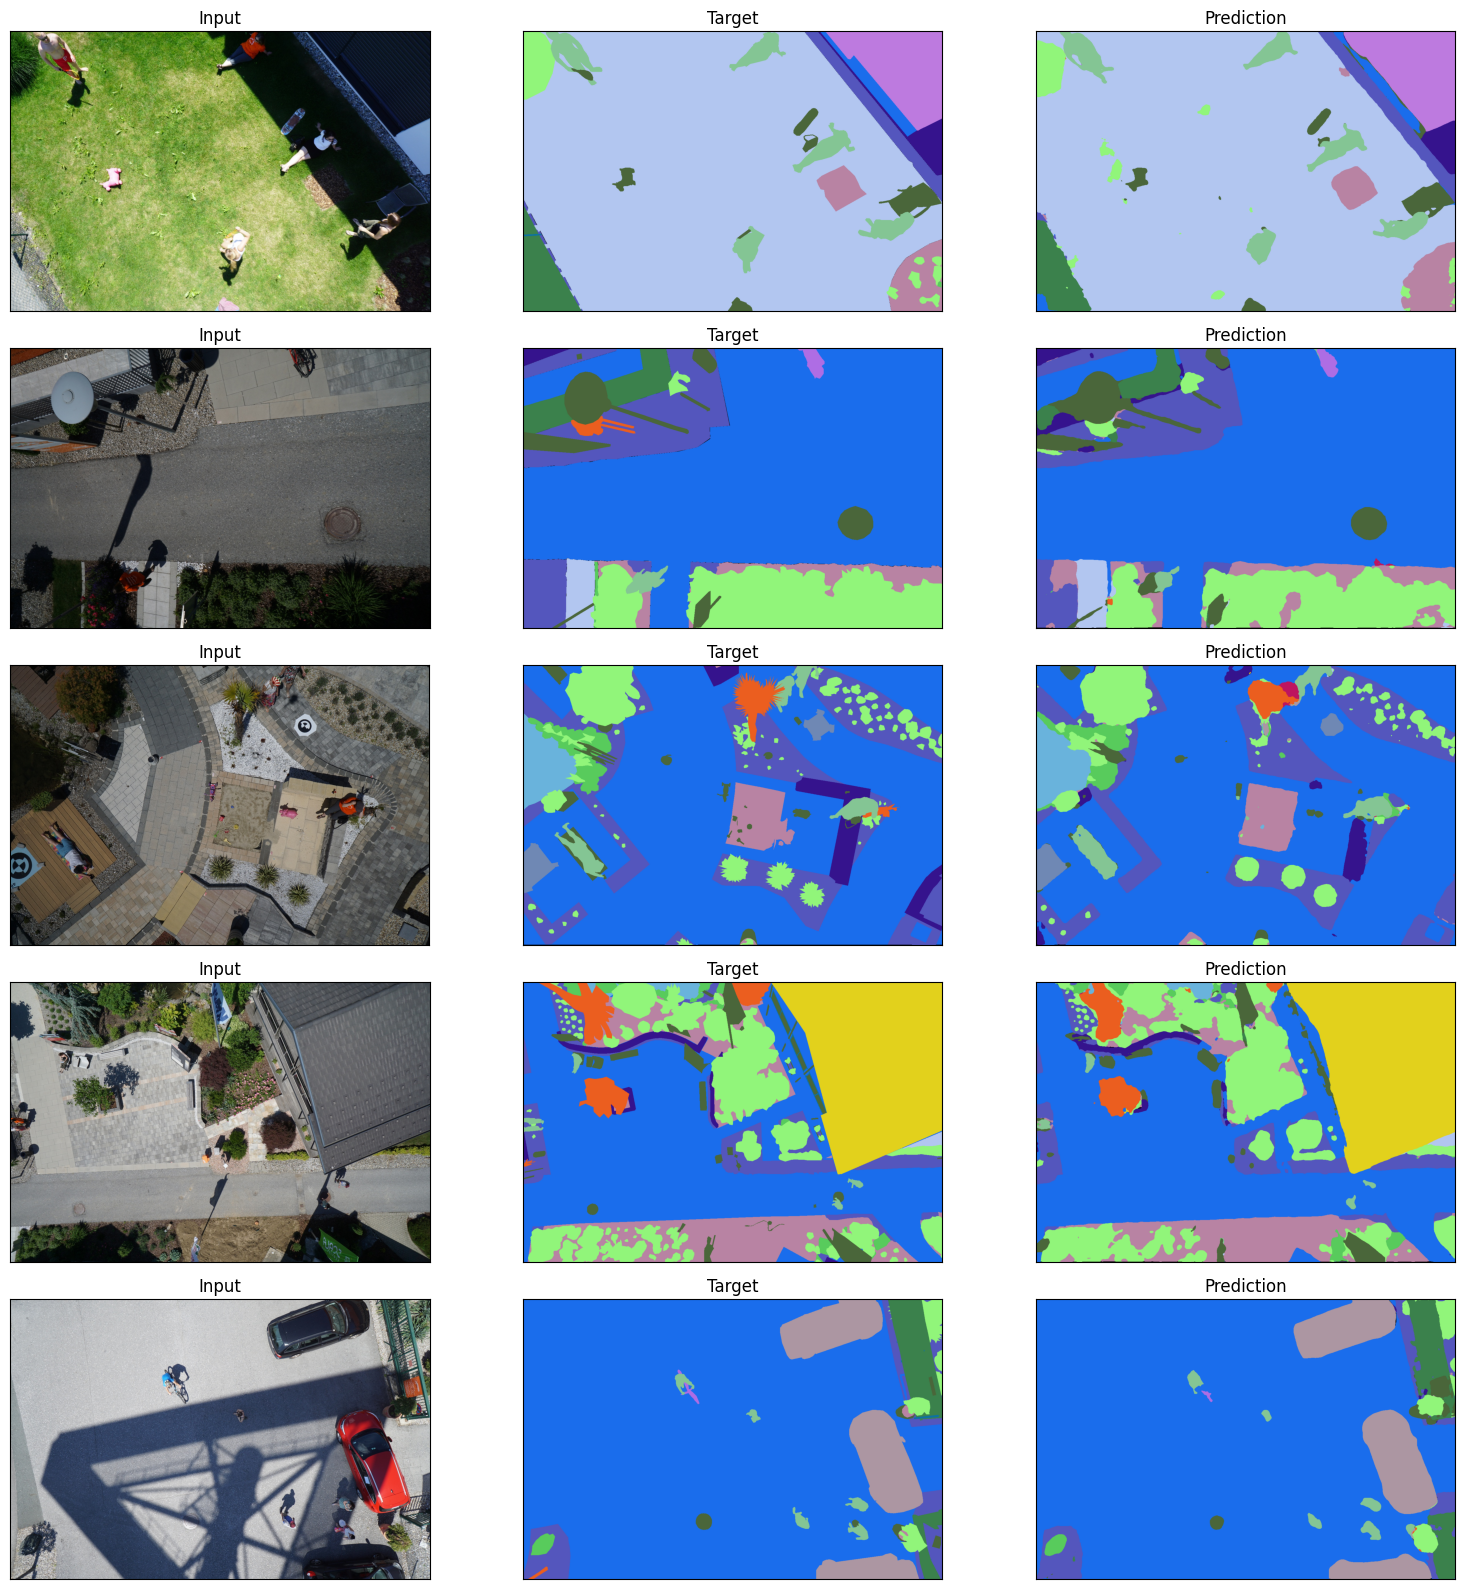

In [33]:
from deepml.transforms import ImageNetInverseTransform

segmentation_task.show_predictions(valid_loader, samples=5, image_inverse_transform=ImageNetInverseTransform())

### 11.1 Load the Best Val Loss Model Weights

In [34]:
!ls -l $wandb.run.dir

total 8233328
-rw-r--r-- 1 root root 702567417 Apr 27 06:48 best_val_model.pt
-rw-r--r-- 1 root root 702567417 Apr 27 05:26 epoch_10_model.pt
-rw-r--r-- 1 root root 702567417 Apr 27 05:43 epoch_15_model.pt
-rw-r--r-- 1 root root 702567417 Apr 27 06:01 epoch_20_model.pt
-rw-r--r-- 1 root root 702567417 Apr 27 06:18 epoch_25_model.pt
-rw-r--r-- 1 root root 702567417 Apr 27 06:35 epoch_30_model.pt
-rw-r--r-- 1 root root 702567417 Apr 27 06:52 epoch_35_model.pt
-rw-r--r-- 1 root root 702567417 Apr 27 07:09 epoch_40_model.pt
-rw-r--r-- 1 root root 702567417 Apr 27 07:25 epoch_45_model.pt
-rw-r--r-- 1 root root 702567417 Apr 27 07:42 epoch_50_model.pt
-rw-r--r-- 1 root root 702566303 Apr 27 05:09 epoch_5_model.pt
-rw-r--r-- 1 root root 702565189 Apr 27 07:42 latest_model.pt
drwxr-xr-x 3 root root      4096 Apr 27 04:55 media
-rw-r--r-- 1 root root     15490 Apr 27 07:42 output.log
-rw-r--r-- 1 root root     14968 Apr 27 04:51 requirements.txt
-rw-r--r-- 1 root root       999 Apr 27 04:51 wan

In [35]:
segmentation_task = Segmentation(model,
                                    model_dir=wandb.run.dir,
                                    load_saved_model=True,
                                    model_file_name="best_val_model.pt",
                                    )

Loading Saved Model Weights: /content/wandb/run-20260427_045135-ms3icv9v/files/best_val_model.pt
Model Weights Successfully Loaded!


### 11.2 Get Validation Dataloader

In [36]:
# Load validation Dataloader.
_, valid_loader = get_dataloader(
    configs=HPARAMS,
    num_workers=TrainingConfig.NUM_WORKERS,
    shuffle_validation=True,
    pin_memory=GPU_AVAILABLE,
    custom_batch_size=InferenceConfig.BATCH_SIZE,
)

### 11.3 Evaluate Model

Get best evaluation metrics using the saved model and log them to WandB.

In [37]:
best_val_metrics = segmentation_task.evaluate(valid_loader, metrics={'best_val_meanIoU': MeanIoU(num_classes=DatasetConfig.NUM_CLASSES),
                                                  "best_val_loss": DiceCOELoss(num_classes=DatasetConfig.NUM_CLASSES)
                                                  })

best_val_metrics

Evaluation  : 100%|██████████| 30/30 [00:13<00:00,  2.22it/s]


{'best_val_meanIoU': 0.8271567662556966, 'best_val_loss': 0.38588176717360817}

In [39]:
for metric, val in best_val_metrics.items():
    wandb.run.summary[metric] = val

In [40]:
run.finish()

learning_rate,████████████████████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss/train,█▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss/val,█▆▅▅▄▃▃▂▂▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
meanIoU/train,▁▃▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇██████████████████████
meanIoU/val,▁▃▄▄▅▅▆▅▇▆▇▇▇▇▇▇▇███████████████████████
best_val_loss,0.38588
best_val_meanIoU,0.82716
learning_rate,3e-05
loss/train,0.22905
loss/val,0.40407
meanIoU/train,0.88113


## 12 Conclusion

* In conclusion, this notebook successfully explored the application of semantic segmentation techniques on an Aerial Drone image dataset.
* The DINO ResNet50 pretrained model weights was utilized for segmentation , demonstrating its effectiveness in accurately segmenting aerial images.
* Custom metrics, including Intersection over Union (IoU), were defined and employed to evaluate the segmentation performance.
* The training process incorporated a combination loss function, combining Dice coefficient and cross entropy, to optimize both localization and classification accuracy.
* The MultiStepLr learning rate scheduler was employed to dynamically adjust the learning rate during training, enhancing convergence. Moreover, automatic mixed-precision training was utilized to improve computational efficiency by leveraging different numerical precisions.
* Additionally, we leveraged WandB for experiment tracking, allowing for efficient monitoring and analysis of the training process. Overall, this notebook highlights the successful implementation of semantic segmentation techniques, utilizing advanced tools and methodologies, to achieve accurate and efficient segmentation on Aerial Drone images.